In [1]:
import stable_worldmodel as swm
from stable_worldmodel.policy import PlanConfig, WorldModelPolicy
from stable_worldmodel.solver import CEMSolver
from stable_worldmodel.wm.utils import load_pretrained
from random import randint
import torch
import cv2
import gymnasium as gym              
from PIL import Image
#from cem import CEM
from omegaconf import OmegaConf
from IPython.display import display

In [2]:
cfg = OmegaConf.load("conf/config.yaml")

In [3]:
dataset = swm.data.load_dataset(
    'tworooms-fov.lance',
    num_steps=2,
    frameskip=1,
    #keys_to_load=['pixels', 'action', 'state', 'target'],
)

In [4]:
episode = dataset.load_episode(99)

In [5]:
env = gym.make('swm/TwoRoom-v1', render_mode='rgb_array')

In [6]:
env.reset(options={'proprio': episode['goal_state'][0].numpy()})
goal = env.render()
env.reset(options={'proprio': episode['state'][0].numpy()})
pixels = env.render()

/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:130: UserWarning: WARN: The obs returned by the `reset()` method was expecting a numpy array, actual type: <class 'torch.Tensor'>
  logger.warn(
/Users/matheoledevehat/Code/leworldmodel/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [7]:
device = 'mps'
model = load_pretrained('tworoom-fov/training-0-alt.pt').to(device).eval()
model.requires_grad_(False)

WorldModel(
  (encoder): ViT(
    (embedding): Linear(in_features=588, out_features=192, bias=True)
    (patch): Patch()
    (layers): ModuleList(
      (0-11): 12 x ModuleDict(
        (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
        (att): Attention(
          (attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
          )
        )
        (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
        (ffn): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=768, out_features=192, bias=True)
        )
      )
    )
    (layer_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
    (last_layer_mlp): Linear(in_features=192, out_features=192, bias=True)
    (batch_norm): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, bias=Tr

In [8]:
import torch
from torch.distributions.normal import Normal
from torch.linalg import vector_norm

def CEM(model, H, N, K, T, action_dim, start, goal, device, a_low, a_high, init_std_frac=0.5, min_std=1e-2, alpha=0.1):
    mean = torch.ones(H, action_dim, device=device)
    std = torch.ones(H, action_dim, device=device)
    
    goal_features = goal.reshape(1, -1)
    best_action_sequence, min_cost = None, float('inf')

    for t in range(T):
        dist = Normal(mean, std)
        candidates = dist.sample((N,))                          # (N, H, action_dim)
        candidates = candidates.clamp(a_low, a_high)   # keep in physical range

        with torch.no_grad():
            height,W,C = start.shape
            start_shaped = start.reshape(1, 1, 1, height, W, C)
            goal_shaped = goal.reshape(1, 1, 1, height, W, C)
            costs = model.get_cost({'pixels': start_shaped, 'goal': goal_shaped}, candidates.unsqueeze(0)).view(-1)

        #with torch.no_grad():
        #    destinations = model.rollout(model.encode_frames(start.reshape(1,1,H,W,C).transpose(-1, -3).transpose(-2, -1)), candidates, H)  # (N, D)
        #costs_2 = vector_norm(goal_features.expand(N, -1) - destinations, dim=1)

        #print(costs, costs_2)
        #assert(costs == costs_2)

        elite_costs, elite = torch.topk(costs, k=K, largest=False)
        elite_cand = candidates[elite]   # (K, H, action_dim)

        new_mean = elite_cand.mean(dim=0)
        new_std  = elite_cand.std(dim=0).clamp_min(min_std)     # variance floor

        mean = (1 - alpha) * new_mean + alpha * mean
        std  = (1 - alpha) * new_std  + alpha * std
        
        if elite_costs[0] < min_cost:
            best_action_sequence = elite_cand[0].clone()        # (H, action_dim)
            min_cost = elite_costs[0].item()

    return best_action_sequence

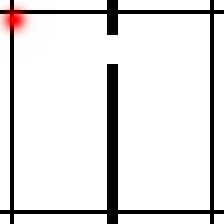

In [9]:
display(Image.fromarray(pixels))

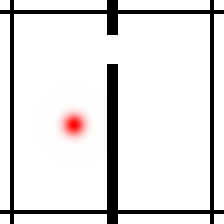

In [10]:
display(Image.fromarray(goal))

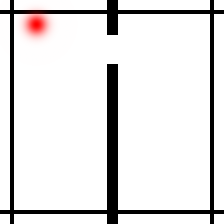

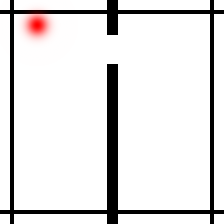

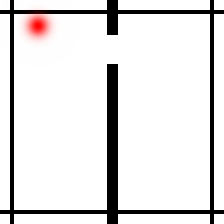

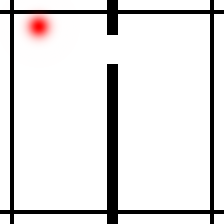

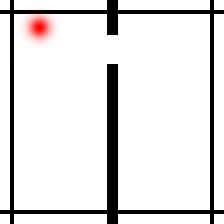

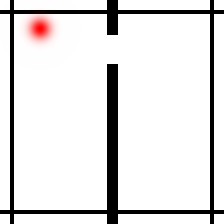

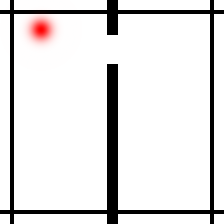

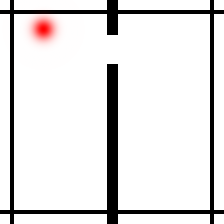

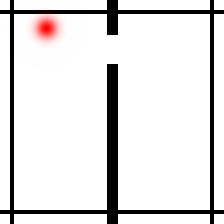

KeyboardInterrupt: 

In [12]:
a_low = -1
a_high = 1
for i in range(100):
    actions = CEM(model, 2, 300, 30, 30, cfg.model.action_dim, torch.tensor(pixels).to(cfg.device), torch.tensor(goal).to(cfg.device), cfg.device, a_low, a_high)
    env.step(actions[0].cpu().numpy())
    pixels = env.render()
    img = Image.fromarray(pixels)
    display(img)

In [19]:
actions = CEM(model, 2, 300, 30, 30, cfg.model.action_dim, torch.tensor(pixels).to(cfg.device)/255, torch.tensor(goal).to(cfg.device)/255, cfg.device) 

In [20]:
env.step(actions[0].cpu().numpy())

(tensor([155.0798, 109.8592, 152.9957, 207.3271, 112.0000,  49.0000,   0.0000,
           0.0000,   0.0000,   0.0000]),
 0.0,
 False,
 False,
 {'env_name': 'TwoRoom',
  'proprio': array([155.07977, 109.85916], dtype=float32),
  'state': array([155.07977, 109.85916], dtype=float32),
  'goal_state': array([152.99574, 207.32706], dtype=float32),
  'distance_to_target': 97.49017333984375})

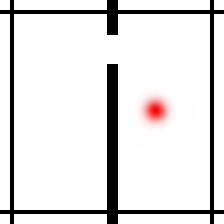

In [21]:
pixels = env.render()
img = Image.fromarray(pixels)
img.show()

In [ ]:
device = 'cuda'
model = load_pretrained('tworoom-fov/training-0-alt.pt').to(device).eval()
model.requires_grad_(False)

num_envs=1

world = swm.World(
    'swm/TwoRoom-v1',
    num_envs=num_envs,
    image_shape=(224, 224),
    max_episode_steps=100,
)

solver = CEMSolver(
    model=model,
    num_samples=300,
    n_steps=10,
    device=device,
)

policy = WorldModelPolicy(
    solver=solver,
    config=PlanConfig(
        horizon=2,
        receding_horizon=2
    ),
)

max_episode = 10000
#episodes_idx = [10]
episodes_idx = [randint(0, max_episode-1) for _ in range(num_envs)]
#min_episode_length = min([dataset.load_episode(ep)['action'].shape[0] for ep in episodes_idx])

world.set_policy(policy)
results = world.evaluate(
    dataset=dataset,
    episodes_idx=episodes_idx,
    start_steps=[0 for _ in range(num_envs)],
    goal_offset=25,
    eval_budget=50,
    video='videos/tworooms',
    callables=[
        {'method': '_set_state', 'args': {'state': {'value': 'state'}}},
        {
            'method': '_set_goal_state',
            'args': {'goal_state': {'value': 'goal_state'}},
        },
    ],
)
world.close()

print(results)